Libs

In [ ]:
# Mount & imports
from google.colab import drive
drive.mount('/drive')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import MobileNet_V2_Weights
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

DATA_DIR  = '/drive/MyDrive/ML/processed_data/'
PLOTS_DIR = '/drive/MyDrive/ML/plots/'
MODEL_DIR = '/drive/MyDrive/ML/modelsfinal/'

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Using device: cuda


data prep and loading

In [ ]:
# Load data
train_data = np.load(DATA_DIR + 'az_dataset_Final.npz')
split_data = np.load(DATA_DIR + 'az_dataset_splits.npz')

X_train = train_data['X_final']
y_train = train_data['y_final']

X_val  = split_data['X_val']
X_test = split_data['X_test']
y_val  = split_data['y_val']
y_test = split_data['y_test']

print(f"X_train : {X_train.shape}, dtype: {X_train.dtype}")
print(f"y_train : {y_train.shape}, dtype: {y_train.dtype}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

NUM_CLASSES = len(np.unique(y_train))
print(f"\nNumber of classes        : {NUM_CLASSES}")
print(f"Augmented training size  : {len(X_train):,}")
print(f"Validation size          : {len(X_val):,}")
print(f"Test size                : {len(X_test):,}")

X_train : (104000, 28, 28, 1), dtype: float32
y_train : (104000,), dtype: int64
X_val   : (30164, 28, 28, 1)
X_test  : (30165, 28, 28, 1)

Number of classes        : 26
Augmented training size  : 104,000
Validation size          : 30,164
Test size                : 30,165


global vars


In [ ]:
IMG_SIZE    = 128
NUM_CLASSES = 26
BATCH_SIZE  = 64

## Transforms
Two separate transforms: one for training, one for val/test

Training gets a small extra augmentation on top of your already-augmented data

Val/test get ONLY the mandatory preprocessing — no randomness

In [ ]:
train_transform = transforms.Compose([
    transforms.ToPILImage(), # transform numpy array to pillow images cuz thats best for our transfer model
    transforms.Resize((IMG_SIZE, IMG_SIZE),interpolation=transforms.InterpolationMode.BILINEAR), #bilinear interpolation smooths pixels while resizing 3shan mtkonsh jaggd aw blocky bi preserver the curves and smoothness
    transforms.RandomRotation(degrees=5), #Each epoch the image rotates randomly 3shan yfhmha, 5 degress 3shan my7slsh distortion ll image aw haga lw rotation kbyra (de kman btsla7 hwar el O/U da)
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), #shifts the image 5% horzontally w 5% vertically
    transforms.ToTensor(),# converts image to numpy tensor (scales pixels + changes shape from (H, W, C)to (C, H, W) )
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),#kyam el imagenet fl mean w std 3la el 3 channels
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3), #for confusion elastic distortion
])
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE),interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
])

In [ ]:
# Early MobileNet filters detect:
# edges
# curves
# corners
# gradients
# Upscaling lets handwritten strokes resemble those learned edge structures.
# no distortion/shearing
# handwriting is fragile
# too much distortion changes class identity


## Dataset

In [ ]:
class CharDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels.astype(np.int64)   #CrossEntropy wants int64
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]  # shape:(28,28,1) Normalize to uint8 if your npz saved as float,ToPILImage() needs either uint8 [0,255] or float [0,1]
        if img.dtype != np.uint8: # float w kda normalization checker
            if img.max() <= 1.0: # if image is normalized nrg3ha 255
                img = (img * 255).astype(np.uint8)
            else:
                img = img.astype(np.uint8)
        if img.ndim == 3 and img.shape[-1] == 1:  # lw kant 28,28,1 bnshyl el graychannel de 3shan n3mlha RGB
            img = img.squeeze(-1)   # (28,28)
        img = np.stack([img, img, img], axis=-1)# Grayscale to RGB: stack the single channel 3 times → (28,28,3) This satisfies MobileNetV2's 3-channel expectation without adding info
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

## DataLoaders

In [ ]:
train_dataset = CharDataset(X_train, y_train, transform=train_transform)
val_dataset   = CharDataset(X_val,   y_val,   transform=val_transform)
test_dataset  = CharDataset(X_test,  y_test,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2,pin_memory=True,persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2,pin_memory=True,persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2,pin_memory=True,persistent_workers=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
imgs, labels = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")   # should be (64, 3, 128, 128)
print(f"Batch label shape : {labels.shape}")  # should be (64,)
print(f"Label range       : {labels.min()} – {labels.max()}")  # 0 to 25

Train batches : 1625
Val batches   : 472
Test batches  : 472

Batch image shape : torch.Size([64, 3, 128, 128])
Batch label shape : torch.Size([64])
Label range       : 0 – 25


## Build Model

In [ ]:
    # MobileNetV2 with a custom classification head.
    # Architecture reasoning:
    # - MobileNetV2 base: frozen initially, loads ImageNet weights
    # - AdaptiveAvgPool: collapses spatial dims to (1,1) regardless of input size
    #   (safer than hardcoding a pool size that depends on IMG_SIZE)
    # - Dropout 0.4: main defense against O/U overconfidence
    # - Dense 512: enough capacity to remap ImageNet features to letter strokes
    # - BatchNorm: stabilizes training, lets us use higher LR safely
    # - Final Dense 26: raw logits (no softmax — nn.CrossEntropyLoss handles that)

    #  Replace the classifier head
    # MobileNetV2's original head: Linear(1280, 1000) for ImageNet
    # We replace it entirely with our 26-class head
    # base.features is the convolutional backbone (what we want to keep frozen)
    # base.classifier is what we're replacing
    # Pull out just the feature extractor

In [ ]:
def build_model(num_classes=26):
    model = models.mobilenet_v2(
        weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
    )
    # Freeze backbone
    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features  # 1280

    model.classifier = nn.Sequential(
    nn.Linear(in_features, 1024), #adapting imagenet features to our handwritting features
    nn.BatchNorm1d(1024), #normalize activations 3shan fwst el trainning btb2a unstable
    nn.LeakyReLU(0.1, inplace=True), #introduces nonlinearity mn 8irha kol el network htkon gaint linear equation w el RELU asln (0,x)"Dying ReLU 3shan mfish neg" de b2a (0.1x,x) 3shan mnl8ish el negative
    nn.Dropout(0.4), #de b2a kol shwya bt disable neurons 3shan my7fzsh haga mara awl wahda w tane wahda w nsh8l talet wahda w hakza randomly

    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.LeakyReLU(0.1, inplace=True),
    nn.Dropout(0.2),

    nn.Linear(512, num_classes), #classifying layer b2a khlas
)
    return model

In [ ]:
model = build_model(num_classes=NUM_CLASSES).to(DEVICE)
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 107MB/s] 


Total params     : 4,076,826
Trainable params : 1,852,954


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total

In [ ]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

    return total_loss / total, correct / total

In [ ]:
# MODEL_DIR= '/drive/MyDrive/'

In [ ]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'],   label='Val')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'],   label='Val')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    #— saves directly to my Drive plots folder
    plt.savefig(MODEL_DIR + f'{title.lower().replace(" ","_")}_curves.png', dpi=120)
    plt.show()

In [ ]:
# ── Loss: label smoothing ─────────────────────────────────────────────────────
# smoothing=0.1 means true class gets 0.9 confidence target instead of 1.0
# This directly fights the O/U overconfidence problem your CNN had
# The model learns "I'm 90% sure this is O, but keep 10% spread across others"
# ── Optimizer: only head params ───────────────────────────────────────────────
# filter(requires_grad) ensures we only touch the classifier, not the frozen base
# ── Scheduler ─────────────────────────────────────────────────────────────────
# ReduceLROnPlateau: halves LR if val_loss doesn't improve for 2 epochs
# Prevents head from oscillating once it starts to converge

In [ ]:
#CROSSENTROPYLOSS WHY?
# takes logits from model
# converts them to probabilities using Softmax
# compares predicted probabilities with true labels
# computes prediction error

PHASE 1 — Training head only (base frozen)
Epoch 01/15 | Train loss: 1.2986 acc: 0.6888 | Val loss: 0.7123 acc: 0.8999 ← best
Epoch 02/15 | Train loss: 1.1175 acc: 0.7495 | Val loss: 0.6767 acc: 0.9055 ← best
Epoch 03/15 | Train loss: 1.0609 acc: 0.7688 | Val loss: 0.6385 acc: 0.9194 ← best
Epoch 04/15 | Train loss: 1.0276 acc: 0.7795 | Val loss: 0.6215 acc: 0.9247 ← best
Epoch 05/15 | Train loss: 0.9982 acc: 0.7879 | Val loss: 0.6140 acc: 0.9252 ← best
Epoch 06/15 | Train loss: 0.9752 acc: 0.7951 | Val loss: 0.5917 acc: 0.9339 ← best
Epoch 07/15 | Train loss: 0.9594 acc: 0.8022 | Val loss: 0.5945 acc: 0.9332
Epoch 08/15 | Train loss: 0.9493 acc: 0.8049 | Val loss: 0.5787 acc: 0.9370 ← best
Epoch 09/15 | Train loss: 0.9360 acc: 0.8098 | Val loss: 0.5761 acc: 0.9380 ← best
Epoch 10/15 | Train loss: 0.9264 acc: 0.8129 | Val loss: 0.5692 acc: 0.9395 ← best
Epoch 11/15 | Train loss: 0.9159 acc: 0.8167 | Val loss: 0.5675 acc: 0.9398 ← best
Epoch 12/15 | Train loss: 0.9087 acc: 0.8191 | Val 

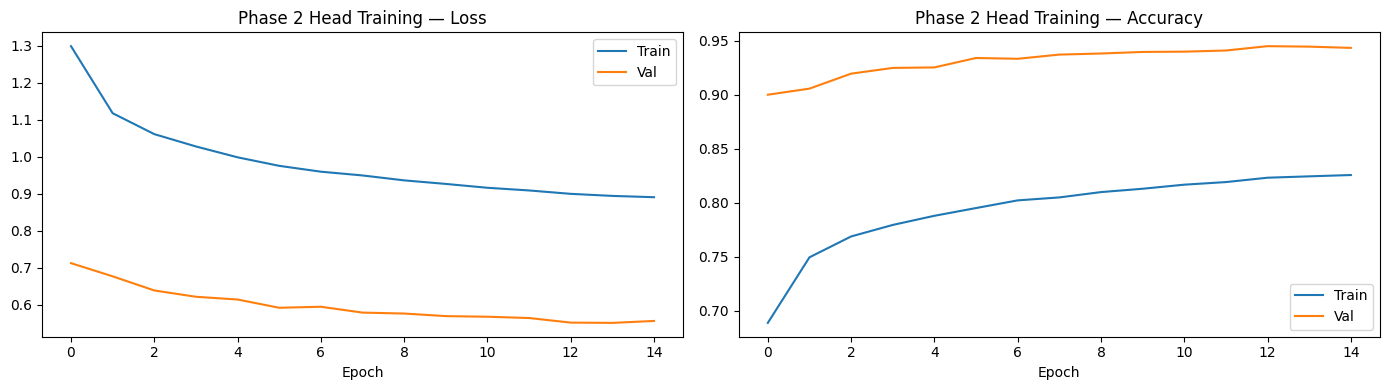

<All keys matched successfully>

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05) #label smoothing bdal ma harf el c ykont [0,0,1,...] btkhle fe confidence kda [0.0125,0.0125,0.95,0.0125,0.0125] 3shan n avoide memorizing,overconfidence,sharp probability spikes
optimizer_phase2 = optim.Adam( #momentum,adaptive learning rates in adams
    filter(lambda p: p.requires_grad, model.parameters()), #ONLY trainable parameters go into optimizer.
    lr=1e-3       # aggressive LR is safe here — base is fully frozen
)
scheduler_phase2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase2, mode='max', factor=0.5, patience=2 #factor(new_lr = old_lr × 0.5),patience 'bsbor 3lih 2 epochs abl ma awte el LR'
)#automatically reduces LR when validation accuracy stops improving

PHASE2_EPOCHS = 15
history_p2 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
print("PHASE 1 — Training head only (base frozen)")
for epoch in range(1, PHASE2_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer_phase2, criterion)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler_phase2.step(val_acc)
    history_p2['train_loss'].append(train_loss)
    history_p2['val_loss'].append(val_loss)
    history_p2['train_acc'].append(train_acc)
    history_p2['val_acc'].append(val_acc)
    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),MODEL_DIR + 'Transfer_Phase2.pth')
        flag = " ← best"
    else:
        flag = ""
    print(f"Epoch {epoch:02d}/{PHASE2_EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f}{flag}")
print(f"\nBest val accuracy (phase 2): {best_val_acc:.4f}")
plot_history(history_p2, "Phase 2 Head Training")
# Load best weights before phase 3
model.load_state_dict(torch.load(MODEL_DIR + 'Transfer_Phase2.pth'))

In [ ]:
model.load_state_dict(torch.load(MODEL_DIR +'Transfer_Phase2.pth'))

<All keys matched successfully>

In [ ]:
# ── Unfreeze the last 30 layers of the backbone ───────────────────────────────
# MobileNetV2's features module has 19 blocks (indices 0-18)
# Blocks 16-18 are the deepest — they detect complex, task-specific patterns
# We unfreeze these so they can adapt from "ImageNet textures" to "letter strokes"
# Blocks 0-15 stay frozen — they already detect edges/curves perfectly
# ── Optimizer: ALL trainable params, but very small LR ────────────────────────
# 1e-5 is ~100x smaller than phase 2
# This nudges the pretrained weights rather than overwriting them
# Using Adam with weight_decay adds L2 regularization — extra help for confusing pairs
# ── Cosine annealing scheduler ────────────────────────────────────────────────
# Smoothly decays LR from 1e-5 → ~0 over all epochs
# Better than step decay for fine-tuning: prevents oscillation near the optimum

Trainable params after unfreezing: 3,946,010
PHASE 2 — Fine-tuning top backbone layers
Epoch 01/25 | Train loss: 0.7522 acc: 0.8759 | Val loss: 0.4729 acc: 0.9708 | LR: 9.99e-06 ← best
Epoch 02/25 | Train loss: 0.6398 acc: 0.9156 | Val loss: 0.4513 acc: 0.9771 | LR: 9.94e-06 ← best
Epoch 03/25 | Train loss: 0.5891 acc: 0.9331 | Val loss: 0.4369 acc: 0.9807 | LR: 9.88e-06 ← best
Epoch 04/25 | Train loss: 0.5565 acc: 0.9443 | Val loss: 0.4321 acc: 0.9818 | LR: 9.78e-06 ← best
Epoch 05/25 | Train loss: 0.5321 acc: 0.9531 | Val loss: 0.4242 acc: 0.9840 | LR: 9.66e-06 ← best
Epoch 06/25 | Train loss: 0.5151 acc: 0.9585 | Val loss: 0.4190 acc: 0.9848 | LR: 9.51e-06 ← best
Epoch 07/25 | Train loss: 0.5028 acc: 0.9627 | Val loss: 0.4171 acc: 0.9848 | LR: 9.34e-06 ← best
Epoch 08/25 | Train loss: 0.4905 acc: 0.9662 | Val loss: 0.4142 acc: 0.9849 | LR: 9.14e-06 ← best
Epoch 09/25 | Train loss: 0.4823 acc: 0.9690 | Val loss: 0.4145 acc: 0.9846 | LR: 8.92e-06
Epoch 10/25 | Train loss: 0.4737 acc: 

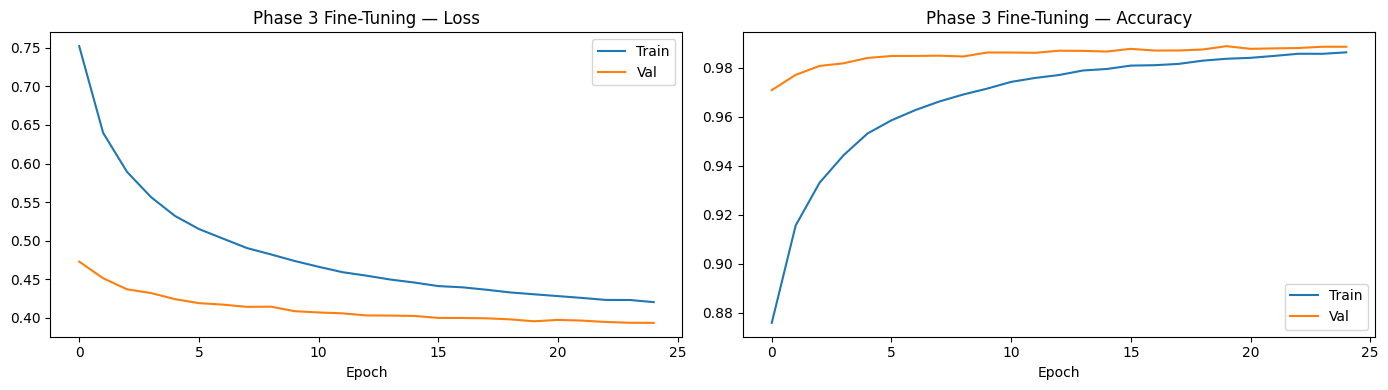

In [ ]:

total_backbone_layers = list(model.features.children())
#criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
unfreeze_from = len(total_backbone_layers) - 10

for layer in total_backbone_layers[unfreeze_from:]:
    for param in layer.parameters():
        param.requires_grad = True

trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params after unfreezing: {trainable_now:,}")

optimizer_phase3 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4    # L2 regularization prevents overfitting on hard pairs
)

PHASE3_EPOCHS = 25
scheduler_phase3 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_phase3,
    T_max=40,     # decay over 40 epochs even though we only run 25
    eta_min=1e-6  # higher floor so it never fully dies
)

history_p3 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc_p3 = 0.0

print("PHASE 2 — Fine-tuning top backbone layers")


for epoch in range(1, PHASE3_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer_phase3, criterion)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)

    scheduler_phase3.step()

    history_p3['train_loss'].append(train_loss)
    history_p3['val_loss'].append(val_loss)
    history_p3['train_acc'].append(train_acc)
    history_p3['val_acc'].append(val_acc)

    if val_acc > best_val_acc_p3:
        best_val_acc_p3 = val_acc
        torch.save(model.state_dict(), MODEL_DIR + 'Transfer_Final.pth')
        flag = " ← best"
    else:
        flag = ""

    current_lr = scheduler_phase3.get_last_lr()[0]
    print(f"Epoch {epoch:02d}/{PHASE3_EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
          f"LR: {current_lr:.2e}{flag}")

print(f"\nBest val accuracy (phase 3): {best_val_acc_p3:.4f}")
plot_history(history_p3, "Phase 3 Fine-Tuning")

Test accuracy: 0.9889  (98.89%)

Classification Report:
              precision    recall  f1-score   support

           A       0.99      1.00      0.99      1152
           B       0.99      0.99      0.99       720
           C       0.99      0.99      0.99      1826
           D       0.95      0.97      0.96       814
           E       0.99      0.99      0.99       906
           F       0.98      1.00      0.99       172
           G       0.97      0.98      0.98       481
           H       0.97      0.98      0.97       596
           I       0.99      1.00      0.99       159
           J       0.98      0.98      0.98       689
           K       0.96      0.99      0.98       473
           L       0.98      0.99      0.99       934
           M       0.99      0.99      0.99      1556
           N       0.99      0.98      0.99      1487
           O       0.99      0.99      0.99      4396
           P       1.00      0.99      0.99      1513
           Q       0.97  

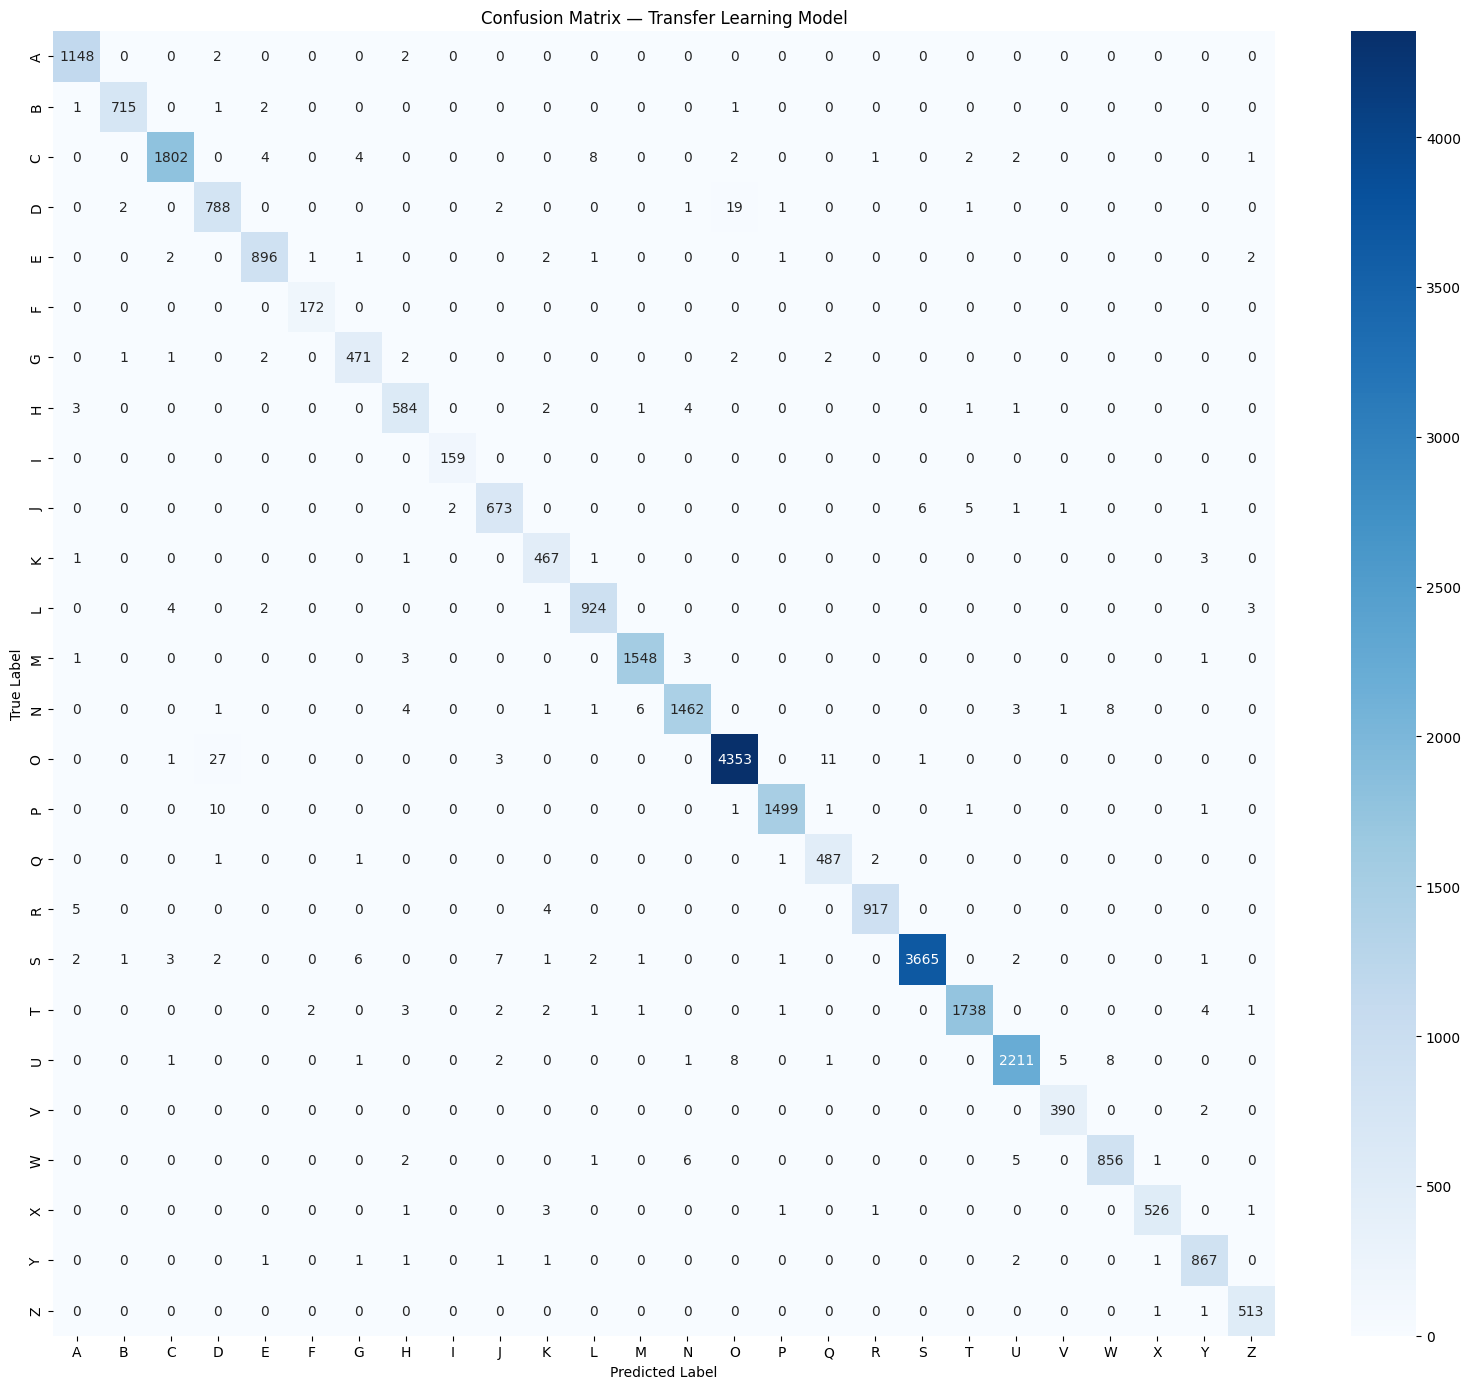


── Confusing Pair Analysis ───────────────────────────────────
Pair           True→Pred errors     Pred→True errors
-------------------------------------------------------
O ↔ U        O→U:      0        U→O:      8
I ↔ L        I→L:      0        L→I:      0
C ↔ G        C→G:      4        G→C:      1
V ↔ Y        V→Y:      2        Y→V:      0
P ↔ F        P→F:      0        F→P:      0

── Per-class accuracy ────────────────────────────────────────
A: 0.997  ███████████████████
B: 0.993  ███████████████████
C: 0.987  ███████████████████
D: 0.968  ███████████████████
E: 0.989  ███████████████████
F: 1.000  ████████████████████
G: 0.979  ███████████████████
H: 0.980  ███████████████████
I: 1.000  ████████████████████
J: 0.977  ███████████████████
K: 0.987  ███████████████████
L: 0.989  ███████████████████
M: 0.995  ███████████████████
N: 0.983  ███████████████████
O: 0.990  ███████████████████
P: 0.991  ███████████████████
Q: 0.990  ███████████████████
R: 0.990  ███████████████████
S

In [ ]:
# Load the best checkpoint from all training
model.load_state_dict(torch.load(MODEL_DIR + 'Transfer_Final.pth'))
model.eval()

#  Collect all predictions
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

#  Overall accuracy
overall_acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {overall_acc:.4f}  ({overall_acc*100:.2f}%)")

#  Full classification report
class_names = [chr(ord('A') + i) for i in range(26)]  # ['A','B',...,'Z']
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

#  Confusion matrix heatmap
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Transfer Learning Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
# AFTER
plt.savefig(MODEL_DIR + 'confusion_matrix.png', dpi=150)
plt.show()

#  Zoom in on your specific confusing pairs
# Add any pair you want to inspect here
confusing_pairs = [
    ('O', 'U'), ('I', 'L'), ('C', 'G'), ('V', 'Y'), ('P', 'F')
]

print("\n── Confusing Pair Analysis ───────────────────────────────────")
print(f"{'Pair':<10} {'True→Pred errors':>20} {'Pred→True errors':>20}")
print("-" * 55)

for a, b in confusing_pairs:
    ia, ib = ord(a) - ord('A'), ord(b) - ord('A')
    # A predicted as B (model confused A for B)
    a_as_b = cm[ia, ib]
    # B predicted as A
    b_as_a = cm[ib, ia]
    print(f"{a} ↔ {b:<6}   {a}→{b}: {a_as_b:>6}        {b}→{a}: {b_as_a:>6}")

# Per-class accuracy
print("\n── Per-class accuracy ────────────────────────────────────────")
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for i, (name, acc) in enumerate(zip(class_names, per_class_acc)):
    bar = '█' * int(acc * 20)
    print(f"{name}: {acc:.3f}  {bar}")